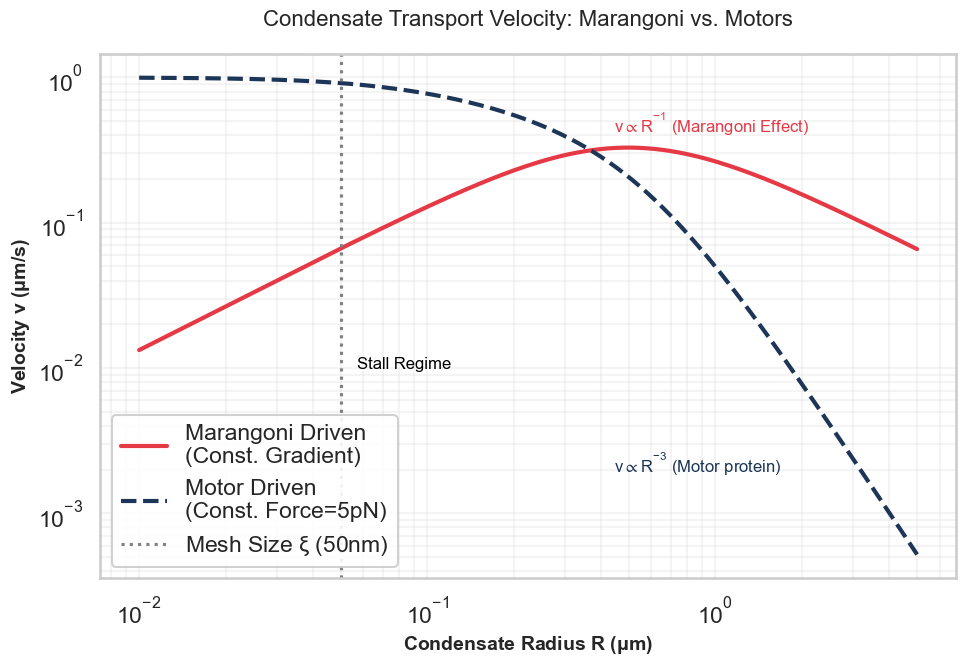

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import seaborn as sns

# --- 1. Parameter Definitions (SI Units) ---
eta_sol = 0.01        # Cytoplasmic solvent viscosity, a baseline value for biomolecular scales (Pa*s)
xi = 50e-9           # Mesh size (m)
G0 = 200          # Scaffold elastic modulus (Pa)
tau = 0.1          # Scaffold relaxation time (s)

# Marangoni parameters
grad_sigma = 4     # Surface tension gradient (N/m^2 or Pa) -> 200 uN/m / 50 um

# Motor parameters
N_motor = 1          # Constant number of motors
F_stall_single = 5e-12 # Stall force per motor (N)
F_stall_total = N_motor * F_stall_single
v_motor_max = 1e-6   # Maximum motor velocity (m/s)

# Radius range R (from 10 nm to 5 um)
R_array = np.logspace(-8, -5.3, 200) # approx 10nm to 5um

# --- 2. Drag Function Definition ---
def drag_force(v, R):
    # Poroelastic term: 6 * pi * eta * (R/xi)^2 * R * v
    # Simplified: 6 * pi * eta * R^3 * v / xi^2
    if R>=xi:
        f_poro = 6 * np.pi * eta_sol * (R**3 / xi**2) * v
    else:
        f_poro = 6 * np.pi * eta_sol * R*v
    
    # Viscoelastic Rearrangement term: G0 * R^2 * (1 - exp(-v*tau/R))
    # Note: avoid divide by zero if R is tiny, but R array is safe
    f_visco = G0 * (R**2) * (1 - np.exp(-v * tau / R))
    
    return f_poro + f_visco

# --- 3. Solve for Marangoni Velocity ---
v_marangoni = []
for R in R_array:
    # Drive: F_M = 2 * pi * R^2 * grad_sigma
    # Equation: Drive - Drag(v) = 0
    drive = 2 * np.pi * (R**2) * grad_sigma
    
    def func_m(v):
        return drive - drag_force(v, R)
    
    # Numerical solution; search range 0 to 1 m/s (sufficiently large)
    try:
        v_sol = brentq(func_m, 0, 1.0)
    except ValueError:
        v_sol = 0.0 # Should not happen given physics
    v_marangoni.append(v_sol)

v_marangoni = np.array(v_marangoni)

# --- 4. Solve for Motor Velocity ---
v_motor = []
for R in R_array:
    # Drive: F_motor(v) = F_stall_total * (1 - v/v_max)
    # Equation: Drive(v) - Drag(v) = 0
    
    def func_motor(v):
        # Physical constraint: v cannot exceed v_max or be less than 0
        if v < 0: return F_stall_total # limit case
        if v > v_motor_max: return -drag_force(v, R) # drive is 0 or negative
        
        drive = F_stall_total * (1 - v / v_motor_max)
        return drive - drag_force(v, R)
    
    try:
        v_sol = brentq(func_motor, 0, v_motor_max)
    except ValueError:
        v_sol = 0.0
    v_motor.append(v_sol)

v_motor = np.array(v_motor)

# --- 5. Plotting ---
sns.set_context("talk")
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(10, 7))

# Convert units for readability (R in um, v in nm/s or um/s)
R_um = R_array * 1e6
v_marangoni_ums = v_marangoni * 1e6
v_motor_ums = v_motor * 1e6

# Plot curves
ax.plot(R_um, v_marangoni_ums, label='Marangoni Driven\n(Const. Gradient)', 
        color='#E63946', linewidth=3)
ax.plot(R_um, v_motor_ums, label='Motor Driven\n(Const. Force=5pN)', 
        color='#1D3557', linewidth=3, linestyle='--')

# Mark mesh size xi
ax.axvline(x=xi*1e6, color='gray', linestyle=':', label=r'Mesh Size $\xi$ (50nm)')

# Axis settings
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'Condensate Radius $R$ ($\mu m$)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'Velocity $v$ ($\mu m/s$)', fontsize=14, fontweight='bold')
ax.set_title('Condensate Transport Velocity: Marangoni vs. Motors', fontsize=16, pad=20)

# Legend and grid
ax.legend(loc='lower left', frameon=True, framealpha=0.9)
ax.grid(True, which="both", ls="-", alpha=0.2)

# Add annotations
ax.text(0.6, 0.85, r'$v \propto R^{-1}$ (Marangoni Effect)', 
        transform=ax.transAxes, color='#E63946', fontsize=12)
ax.text(0.3, 0.4, r'Stall Regime', 
        transform=ax.transAxes, color='black', fontsize=12)
ax.text(0.6, 0.2, r'$v \propto R^{-3}$ (Motor protein)', 
        transform=ax.transAxes, color='#1D3557', fontsize=12)

plt.tight_layout()

# Save/Show
plt.savefig('condensate_dynamics.svg', format='svg')
plt.show()

<>:168: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:168: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\1\AppData\Local\Temp\ipykernel_24344\691792986.py:168: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_ylabel(f'Displacement in {int(t_window)}s, $\Delta x$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)


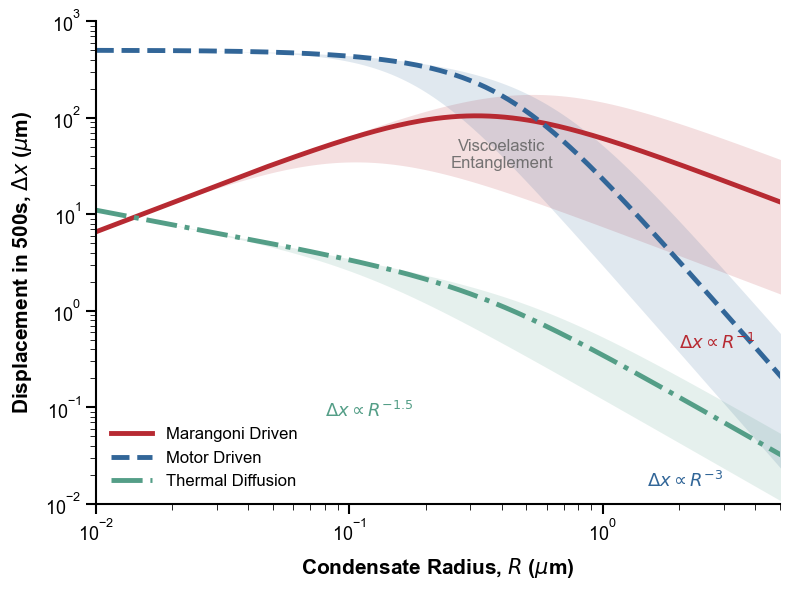

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- 1. Parameter Definition System (supports fixed values or [min, max] ranges) ---
# Range parameters are averaged for the solid line; boundary combinations define the shaded range
params = {
    'eta_sol': 0.01,      # Solvent viscosity (Pa*s)
    'xi': [15e-9, 75e-9],        # Mesh size (m)
    'G0': 100,             # Scaffold elastic modulus (Pa)
    'tau': 0.1,                   # Scaffold relaxation time (s) [fixed-value example]
    'grad_sigma': 2,         # Surface tension gradient (N/m^2 or Pa)
    'N_motor': 1,                 # Constant number of motors
    'F_stall_single': 5e-12,      # Stall force per motor (N)
    'v_motor_max': 1e-6,        # Maximum motor velocity (m/s)
    'T': 300,          # Temperature range (K)
    't_window': 500.0             # Observation time window (s)
}

# --- 2. Parameter Parsing Helper Functions ---
def get_p(key, mode='mid'):
    """根据需要获取参数的中位值、最小值或最大值"""
    val = params[key]
    if isinstance(val, (list, tuple)):
        if mode == 'mid': return np.mean(val)
        elif mode == 'min': return min(val)
        elif mode == 'max': return max(val)
    return val

kB = 1.38e-23  # Boltzmann constant (J/K)
R_array = np.logspace(-8, -5, 200) # R from 10 nm (0.01 um) to 5 um

# --- 3. Core Physics Function Definitions ---
def drag_force(v, R, eta, xi, G0, tau):
    """综合孔隙粘弹性阻力"""
    if R >= xi:
        f_poro = 6 * np.pi * eta * (R**3 / xi**2) * v
    else:
        f_poro = 6 * np.pi * eta * R * v
    f_visco = G0 * (R**2) * (1 - np.exp(-v * tau / R))
    return f_poro + f_visco

def calc_D(R, eta, xi, G0, tau, T):
    """计算零剪切极限下的扩散系数"""
    if R >= xi:
        zeta_poro = 6 * np.pi * eta * (R**3 / xi**2)
    else:
        zeta_poro = 6 * np.pi * eta * R
    zeta_visco = G0 * R * tau
    zeta_total = zeta_poro + zeta_visco
    return kB * T / zeta_total

def get_displacements(mode='mid'):
    """
    根据模式计算位移:
    'mid': 取所有参数均值
    'fast': 取阻力最小、动力最大的边界条件
    'slow': 取阻力最大、动力最小的边界条件
    """
    # Dynamically configure boundary conditions
    if mode == 'mid':
        eta, xi_val, G0, tau = get_p('eta_sol'), get_p('xi'), get_p('G0'), get_p('tau')
        grad_s, T_val = get_p('grad_sigma'), get_p('T')
        F_stall = get_p('N_motor') * get_p('F_stall_single')
    elif mode == 'fast':
        eta, xi_val, G0, tau = get_p('eta_sol','min'), get_p('xi','max'), get_p('G0','min'), get_p('tau','min')
        grad_s, T_val = get_p('grad_sigma','max'), get_p('T','max')
        F_stall = get_p('N_motor','max') * get_p('F_stall_single','max')
    elif mode == 'slow':
        eta, xi_val, G0, tau = get_p('eta_sol','max'), get_p('xi','min'), get_p('G0','max'), get_p('tau','max')
        grad_s, T_val = get_p('grad_sigma','min'), get_p('T','min')
        F_stall = get_p('N_motor','min') * get_p('F_stall_single','min')

    v_max = get_p('v_motor_max')
    t_win = get_p('t_window')
    
    disp_maran, disp_motor, disp_diff = [], [], []
    
    for R in R_array:
        # 1. Marangoni
        drive_m = 2 * np.pi * (R**2) * grad_s
        def func_m(v): return drive_m - drag_force(v, R, eta, xi_val, G0, tau)
        try:
            v_m = brentq(func_m, 0, 10.0)
        except ValueError:
            v_m = 0.0
        disp_maran.append(v_m * t_win)
        
        # 2. Motor
        def func_motor(v):
            if v < 0: return F_stall
            if v > v_max: return -drag_force(v, R, eta, xi_val, G0, tau)
            return F_stall * (1 - v / v_max) - drag_force(v, R, eta, xi_val, G0, tau)
        try:
            v_mot = brentq(func_motor, 0, v_max)
        except ValueError:
            v_mot = 0.0
        disp_motor.append(v_mot * t_win)
        
        # 3. Diffusion (sqrt(6Dt))
        D = calc_D(R, eta, xi_val, G0, tau, T_val)
        disp_diff.append(np.sqrt(6 * D * t_win))
        
    return np.array(disp_maran), np.array(disp_motor), np.array(disp_diff)

# Compute three datasets
d_mar_mid, d_mot_mid, d_dif_mid = get_displacements('mid')
d_mar_fast, d_mot_fast, d_dif_fast = get_displacements('fast')
d_mar_slow, d_mot_slow, d_dif_slow = get_displacements('slow')

# --- 4. Advanced Visual Presentation ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

fig, ax = plt.subplots(figsize=(8, 6))

R_um = R_array * 1e6
to_um = 1e6
t_window = get_p('t_window')

# Color settings
col_maran = '#B72A32'  # Rich red
col_motor = '#326698'  # Rich blue
col_diff  = '#549E87'  # Rich cyan

# 4.1 Core optimization: grayscale gradient background (enhances the poroelastic effect)
# Gradient from the median xi value to the plot boundary
#xi_mid_um = get_p('xi', 'mid') * 1e6
#bg_x = np.logspace(np.log10(xi_mid_um), np.log10(10), 100)
#bg_alphas = np.linspace(0, 0.5, len(bg_x)) # Maximum opacity 0.12; never overpower the plot

#for i in range(len(bg_x)-1):
    #ax.axvspan(bg_x[i], bg_x[i+1], color='#666666', alpha=bg_alphas[i], lw=0, zorder=0)

# 4.2 Plot the boundary shading (Z-order prevents it from being obscured)
ax.fill_between(R_um, d_mar_slow*to_um, d_mar_fast*to_um, color=col_maran, alpha=0.15, lw=0, zorder=1)
ax.fill_between(R_um, d_mot_slow*to_um, d_mot_fast*to_um, color=col_motor, alpha=0.15, lw=0, zorder=1)
ax.fill_between(R_um, d_dif_slow*to_um, d_dif_fast*to_um, color=col_diff, alpha=0.15, lw=0, zorder=1)

# 4.3 Plot the median solid/dashed lines
ax.plot(R_um, d_mar_mid*to_um, label='Marangoni Driven', color=col_maran, linewidth=3.5, zorder=2)
ax.plot(R_um, d_mot_mid*to_um, label='Motor Driven', color=col_motor, linewidth=3.5, linestyle='--', zorder=2)
ax.plot(R_um, d_dif_mid*to_um, label='Thermal Diffusion', color=col_diff, linewidth=3.5, linestyle='-.', zorder=2)

# Clean up axes and boundaries
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.01, 5)
ax.set_ylim(1e-2, 1e3)

# Core optimization: completely remove the top and right spines and ticks
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.tick_params(axis='both', which='both', top=False, right=False)
ax.grid(False) # Disable grid

# Labels and text annotations
ax.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)
ax.set_ylabel(f'Displacement in {int(t_window)}s, $\Delta x$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)
ax.tick_params(axis='both', which='major', labelsize=13, length=7)
ax.tick_params(axis='both', which='minor', length=4)

# Add feature labels
ax.text(0.4, 30, 'Viscoelastic\nEntanglement', color='#666666', fontsize=12, alpha=0.9, ha='center', zorder=3)
ax.text(2.0, 0.4, r'$\Delta x \propto R^{-1}$', color=col_maran, fontsize=13)
ax.text(1.5, 0.015, r'$\Delta x \propto R^{-3}$', color=col_motor, fontsize=13)
ax.text(0.08, 0.08, r'$\Delta x \propto R^{-1.5}$', color=col_diff, fontsize=13)

# Mesh characteristic size line
#ax.axvline(x=xi_mid_um, color='#999999', linestyle=':', linewidth=2, zorder=0)
#ax.text(xi_mid_um, 1.2e3, r'$\xi$', color='#888888', fontsize=14, ha='center', va='bottom', clip_on=False)

# Legend settings
ax.legend(loc='lower left', frameon=False, fontsize=12, handlelength=2.5)

plt.tight_layout()
plt.savefig('Displacement_Landscape_Optimized1.svg', dpi=600, bbox_inches='tight')
plt.show()

<>:155: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:155: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\1\AppData\Local\Temp\ipykernel_16316\345148242.py:155: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_ylabel(f'Displacement in {int(t_window)}s, $\Delta x$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)


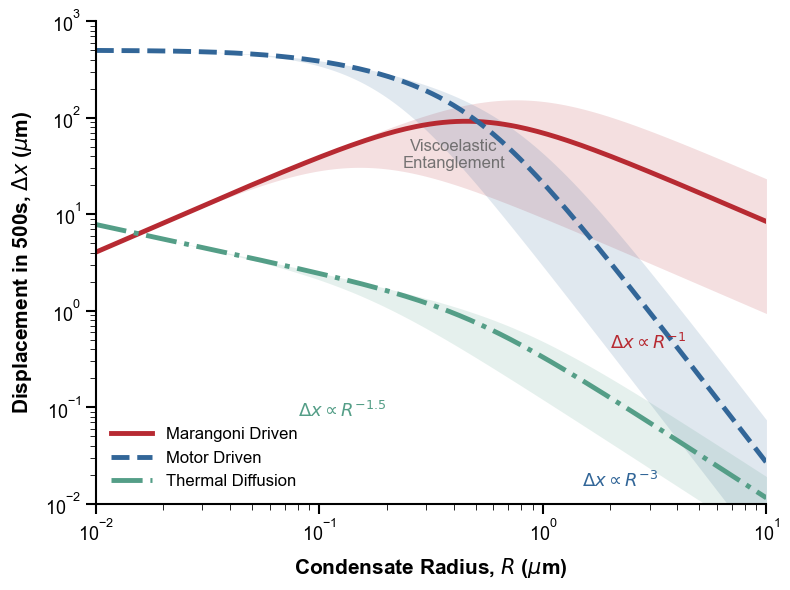

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- 1. Parameter Definition System (supports fixed values or [min, max] ranges) ---
params = {
    'eta_sol': 0.01,              # Solvent viscosity (Pa*s)
    'xi': [15e-9, 75e-9],         # Mesh size (m)
    'G0': 200,                    # Scaffold elastic modulus (Pa)
    'tau': 0.1,                   # Scaffold relaxation time (s) [fixed-value example]
    'grad_sigma': 2.5,              # Surface tension gradient (N/m^2 or Pa)
    'N_motor': 1,                 # Constant number of motors
    'F_stall_single': 5e-12,      # Stall force per motor (N)
    'v_motor_max': 1e-6,          # Maximum motor velocity (m/s)
    'T': 300,                     # Temperature range (K)
    't_window': 500.0              # Observation time window (s)
}

# --- 2. Parameter Parsing Helper Functions ---
def get_p(key, mode='mid'):
    val = params[key]
    if isinstance(val, (list, tuple)):
        if mode == 'mid': return np.mean(val)
        elif mode == 'min': return min(val)
        elif mode == 'max': return max(val)
    return val

kB = 1.38e-23  # Boltzmann constant (J/K)
R_array = np.logspace(-8, -5, 200) # R from 10 nm (0.01 um) to 5 um

# --- 3. Core Physics Function Definitions ---
def drag_force(v, R, eta, xi, G0, tau):
    if R >= xi:
        f_poro = 6 * np.pi * eta * (R**3 / xi**2) * v
    else:
        f_poro = 6 * np.pi * eta * R * v
    f_visco = G0 * (R**2) * (1 - np.exp(-v * tau / R))
    return f_poro + f_visco

def calc_D(R, eta, xi, G0, tau, T):
    if R >= xi:
        zeta_poro = 6 * np.pi * eta * (R**3 / xi**2)
    else:
        zeta_poro = 6 * np.pi * eta * R
    zeta_visco = G0 * R * tau
    zeta_total = zeta_poro + zeta_visco
    return kB * T / zeta_total

def get_displacements(mode='mid'):
    if mode == 'mid':
        eta, xi_val, G0, tau = get_p('eta_sol'), get_p('xi'), get_p('G0'), get_p('tau')
        grad_s, T_val = get_p('grad_sigma'), get_p('T')
        F_stall = get_p('N_motor') * get_p('F_stall_single')
    elif mode == 'fast':
        eta, xi_val, G0, tau = get_p('eta_sol','min'), get_p('xi','max'), get_p('G0','min'), get_p('tau','min')
        grad_s, T_val = get_p('grad_sigma','max'), get_p('T','max')
        F_stall = get_p('N_motor','max') * get_p('F_stall_single','max')
    elif mode == 'slow':
        eta, xi_val, G0, tau = get_p('eta_sol','max'), get_p('xi','min'), get_p('G0','max'), get_p('tau','max')
        grad_s, T_val = get_p('grad_sigma','min'), get_p('T','min')
        F_stall = get_p('N_motor','min') * get_p('F_stall_single','min')

    v_max = get_p('v_motor_max')
    t_win = get_p('t_window')
    
    disp_maran, disp_motor, disp_diff = [], [], []
    
    for R in R_array:
        # 1. Marangoni
        drive_m = 2 * np.pi * (R**2) * grad_s
        def func_m(v): return drive_m - drag_force(v, R, eta, xi_val, G0, tau)
        try:
            v_m = brentq(func_m, 0, 10.0)
        except ValueError:
            # Fix 1: replace 0.0 with a tiny positive number to prevent log(0) from crashing and hiding ticks
            v_m = 1e-20 
        disp_maran.append(v_m * t_win)
        
        # 2. Motor
        def func_motor(v):
            if v < 0: return F_stall
            if v > v_max: return -drag_force(v, R, eta, xi_val, G0, tau)
            return F_stall * (1 - v / v_max) - drag_force(v, R, eta, xi_val, G0, tau)
        try:
            v_mot = brentq(func_motor, 0, v_max)
        except ValueError:
            # Fix 1: same as above
            v_mot = 1e-20
        disp_motor.append(v_mot * t_win)
        
        # 3. Diffusion
        D = calc_D(R, eta, xi_val, G0, tau, T_val)
        disp_diff.append(np.sqrt(6 * D * t_win))
        
    return np.array(disp_maran), np.array(disp_motor), np.array(disp_diff)

d_mar_mid, d_mot_mid, d_dif_mid = get_displacements('mid')
d_mar_fast, d_mot_fast, d_dif_fast = get_displacements('fast')
d_mar_slow, d_mot_slow, d_dif_slow = get_displacements('slow')

# --- 4. Advanced Visual Presentation ---
plt.rcParams.update({
    "font.family": "sans-serif",
    # Fix 2: add "DejaVu Sans" as a cross-platform fallback font to prevent blank labels when Arial is unavailable
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

fig, ax = plt.subplots(figsize=(8, 6))

R_um = R_array * 1e6
to_um = 1e6
t_window = get_p('t_window')

# Color settings
col_maran = '#B72A32'  
col_motor = '#326698'  
col_diff  = '#549E87'  

# 4.2 Plot the boundary shading 
ax.fill_between(R_um, d_mar_slow*to_um, d_mar_fast*to_um, color=col_maran, alpha=0.15, lw=0, zorder=1)
ax.fill_between(R_um, d_mot_slow*to_um, d_mot_fast*to_um, color=col_motor, alpha=0.15, lw=0, zorder=1)
ax.fill_between(R_um, d_dif_slow*to_um, d_dif_fast*to_um, color=col_diff, alpha=0.15, lw=0, zorder=1)

# 4.3 Plot the median solid/dashed lines
ax.plot(R_um, d_mar_mid*to_um, label='Marangoni Driven', color=col_maran, linewidth=3.5, zorder=2)
ax.plot(R_um, d_mot_mid*to_um, label='Motor Driven', color=col_motor, linewidth=3.5, linestyle='--', zorder=2)
ax.plot(R_um, d_dif_mid*to_um, label='Thermal Diffusion', color=col_diff, linewidth=3.5, linestyle='-.', zorder=2)

# Clean up axes and boundaries
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.01, 10)
ax.set_ylim(1e-2, 1e3)

# Core optimization: completely remove the top and right spines and ticks
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(True)

# Fix 3: explicitly set bottom=True and left=True and ensure labels are displayed
ax.tick_params(axis='both', which='both', 
               bottom=True, top=False, 
               left=True, right=False, 
               labelbottom=True, labelleft=True)
ax.grid(False) 

# Labels and text annotations
ax.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)
ax.set_ylabel(f'Displacement in {int(t_window)}s, $\Delta x$ ($\mu$m)', fontsize=15, fontweight='bold', labelpad=8)
ax.tick_params(axis='both', which='major', labelsize=13, length=7)
ax.tick_params(axis='both', which='minor', length=4)

# Add feature labels
ax.text(0.4, 30, 'Viscoelastic\nEntanglement', color='#666666', fontsize=12, alpha=0.9, ha='center', zorder=3)
ax.text(2.0, 0.4, r'$\Delta x \propto R^{-1}$', color=col_maran, fontsize=13)
ax.text(1.5, 0.015, r'$\Delta x \propto R^{-3}$', color=col_motor, fontsize=13)
ax.text(0.08, 0.08, r'$\Delta x \propto R^{-1.5}$', color=col_diff, fontsize=13)

ax.legend(loc='lower left', frameon=False, fontsize=12, handlelength=2.5)

plt.tight_layout()
#plt.savefig('Displacement_Landscape_Optimized_new.svg', dpi=600, bbox_inches='tight')
plt.show()

Calculating Data for Figure 1...
Calculating Data for Figure 2 (this may take a moment)...
Plots generated successfully with smooth transitions and enhanced labels.


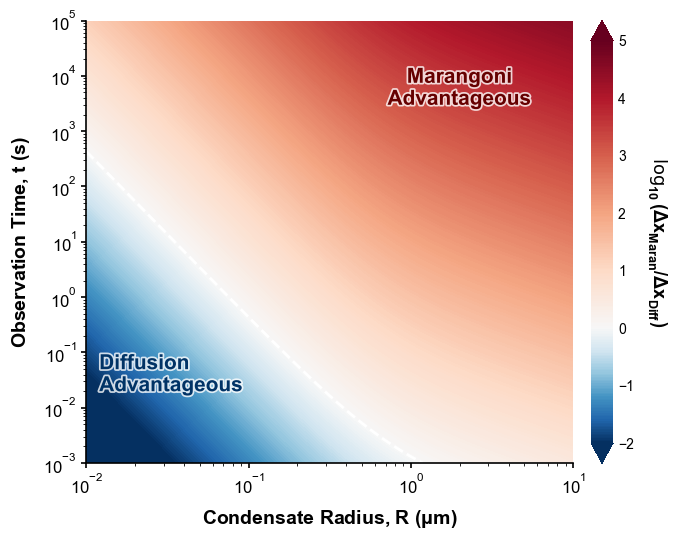

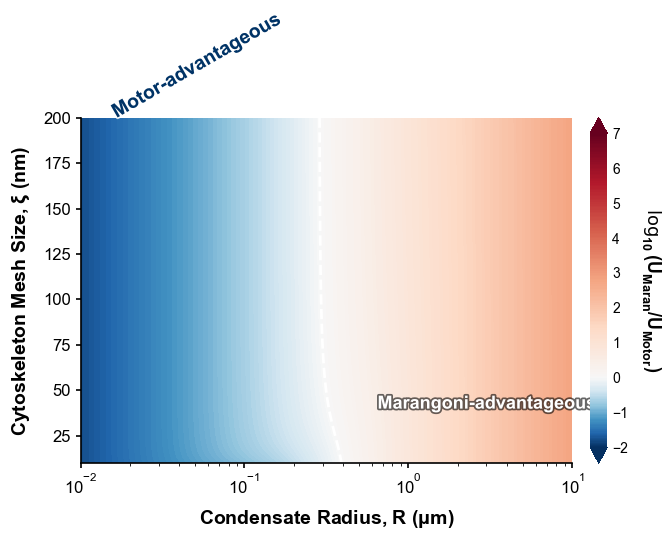

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe # Import the effects library used for text outlines

# ==========================================
# 1. Core physical parameter definitions (SI units)
# ==========================================
eta_sol = 0.01          # Cytoplasmic solvent viscosity (Pa*s)
G0 = 200               # Scaffold elastic modulus (Pa)
tau = 0.1              # Scaffold relaxation time (s)
grad_sigma = 5         # Surface tension gradient (N/m^2 or Pa)
N_motor = 1            # Constant number of motors
F_stall_single = 5e-12 # Stall force per motor (N)
F_stall_total = N_motor * F_stall_single
v_motor_max = 1e-6   # Maximum motor velocity (m/s)

kB = 1.38e-23          # Boltzmann constant (J/K)
T_temp = 300.0         # Absolute temperature (K)

# Define a physically meaningful minimum velocity floor to prevent logarithmic overflow
V_FLOOR = 1e-15 

# ==========================================
# 2. Core dynamics solver for improved numerical stability
# ==========================================
def drag_force(v, R, xi):
    """涵盖多尺度效应的孔隙粘弹性阻力"""
    # Ensure v is nonnegative to prevent errors in the exponential term
    v_eff = np.maximum(v, 0.0)
    if R >= xi:
        f_poro = 6 * np.pi * eta_sol * (R**3 / xi**2) * v_eff
    else:
        f_poro = 6 * np.pi * eta_sol * R * v_eff
    # Add a small value to prevent division by zero
    R_eff = np.maximum(R, 1e-12)
    f_visco = G0 * (R_eff**2) * (1 - np.exp(-v_eff * tau / R_eff))
    return f_poro + f_visco

def calc_diffusion_coeff(R, xi):
    """零剪切极限下的有效扩散系数"""
    if R >= xi:
        zeta_poro = 6 * np.pi * eta_sol * (R**3 / xi**2)
    else:
        zeta_poro = 6 * np.pi * eta_sol * R
    zeta_visco = G0 * R * tau
    zeta_total = zeta_poro + zeta_visco
    return kB * T_temp / zeta_total

def get_v_maran_safe(R, xi):
    drive = 2 * np.pi * (R**2) * grad_sigma
    def func_m(v): return drive - drag_force(v, R, xi)
    
    # Check boundary conditions; return the floor if the driving force cannot overcome the minimum drag
    try:
        if func_m(V_FLOOR) < 0: return V_FLOOR
        root = brentq(func_m, V_FLOOR, 10.0) # Set the upper search bound to 10 m/s, which is sufficiently large
        return np.maximum(root, V_FLOOR)
    except Exception:
        return V_FLOOR

def get_v_motor_safe(R, xi):
    def func_mot(v):
        # Return a sentinel value outside the physical constraint interval to guide the solver
        if v <= V_FLOOR: return F_stall_total - drag_force(V_FLOOR, R, xi)
        if v >= v_motor_max: return -drag_force(v_motor_max, R, xi)
        drive = F_stall_total * (1 - v / v_motor_max)
        return drive - drag_force(v, R, xi)
    
    try:
        # Check whether this motor cannot pull the load at all (stall force below static drag)
        if func_mot(V_FLOOR) < 0: return V_FLOOR
        root = brentq(func_mot, V_FLOOR, v_motor_max)
        return np.maximum(root, V_FLOOR)
    except Exception:
        return V_FLOOR

# ==========================================
# 3. Global advanced visual settings (Nature/Science style)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "axes.linewidth": 1.2, # Make the spines slightly thinner for a more refined look
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "mathtext.default": "regular" # Keep formula fonts non-italic as well
})

# Define text-outline effects to emphasize light text on dark backgrounds, and vice versa
dark_text_outline = [pe.withStroke(linewidth=2.5, foreground='white', alpha=0.8)]
light_text_outline = [pe.withStroke(linewidth=2.5, foreground='black', alpha=0.6)]

# Increase computational grid density for a smoother physical field
N_GRID = 400 

# ==========================================
# Figure 1: Displacement ratio phase map (R vs. time)
# ==========================================
R_arr1 = np.logspace(-8, -5, N_GRID)      # 10 nm to 10 um
t_arr1 = np.logspace(-3, 5, N_GRID)       # 1 ms to 100,000 s
xi_fixed = 75e-9

R_grid1, T_grid1 = np.meshgrid(R_arr1, t_arr1)
Ratio_M_vs_D = np.zeros_like(R_grid1)

print("Calculating Data for Figure 1...")
v_maran_arr1 = np.array([get_v_maran_safe(r, xi_fixed) for r in R_arr1])
D_arr1 = np.array([calc_diffusion_coeff(r, xi_fixed) for r in R_arr1])

# Use broadcasting for efficient computation
disp_M_grid = v_maran_arr1[np.newaxis, :] * T_grid1
disp_D_grid = np.sqrt(6 * D_arr1[np.newaxis, :] * T_grid1)
Ratio_M_vs_D = disp_M_grid / np.maximum(disp_D_grid, V_FLOOR*1e-3) # Prevent division by zero

log_ratio1 = np.log10(Ratio_M_vs_D)

# --- Plot 1 ---
fig1, ax1 = plt.subplots(figsize=(7, 5.5))

# Set the color scale range and center
vmin1, vmax1 = -2, 5
norm1 = mcolors.TwoSlopeNorm(vmin=vmin1, vcenter=0, vmax=vmax1)
cmap_coolwarm = plt.get_cmap('RdBu_r')
# Use enough color levels (levels=256) to simulate a continuous smooth transition
levels1 = np.linspace(vmin1, vmax1, 256)

# Core improvement: use contourf instead of pcolormesh for a silky-smooth result
cf1 = ax1.contourf(R_grid1 * 1e6, T_grid1, log_ratio1, levels=levels1, cmap=cmap_coolwarm, norm=norm1, extend='both')

# Draw the equality contour (Ratio = 1)
CS1 = ax1.contour(R_grid1 * 1e6, T_grid1, log_ratio1, levels=[0], colors='white', linewidths=2, linestyles='--')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.tick_params(top=False, right=False, which='both')

ax1.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontsize=14, fontweight='bold', labelpad=8)
ax1.set_ylabel(r'Observation Time, $t$ (s)', fontsize=14, fontweight='bold', labelpad=8)
ax1.tick_params(labelsize=12)

# Optimize the colorbar
cbar1 = fig1.colorbar(cf1, ax=ax1, pad=0.03, ticks=np.arange(vmin1, vmax1+1))
cbar1.set_label(r'$\log_{10}(\Delta x_{Maran} / \Delta x_{Diff})$', fontsize=13, fontweight='bold', rotation=270, labelpad=25)
cbar1.outline.set_visible(False) # Remove the colorbar frame for a more modern look
cbar1.ax.tick_params(length=0) # Remove colorbar tick marks

# Region annotation text (with text-outline effects)
ax1.text(0.012, 2e-2, 'Diffusion\nAdvantageous', color='#003366', fontsize=15, fontweight='bold', ha='left', path_effects=dark_text_outline)
ax1.text(2.0, 3e3, 'Marangoni\nAdvantageous', color='#660000', fontsize=15, fontweight='bold', ha='center', path_effects=dark_text_outline)

plt.tight_layout()
plt.savefig('Fig1_Smooth_Time_vs_Radius.svg', dpi=600, bbox_inches='tight')


# ==========================================
# Figure 2: Velocity ratio phase map (R vs. mesh size)
# ==========================================
R_arr2 = np.logspace(-8, -5, N_GRID)       # 10 nm to 10 um
xi_arr2 = np.linspace(10e-9, 200e-9, N_GRID) # 10 nm to 200 nm

R_grid2, Xi_grid2 = np.meshgrid(R_arr2, xi_arr2)
Ratio_M_vs_Mot = np.zeros_like(R_grid2)

print("Calculating Data for Figure 2 (this may take a moment)...")
# A double loop is needed to compute the physical state at each grid point
for i in range(N_GRID):
    for j in range(N_GRID):
        r_val = R_arr2[j]
        xi_val = xi_arr2[i]
        v_mar = get_v_maran_safe(r_val, xi_val)
        v_mot = get_v_motor_safe(r_val, xi_val)
        Ratio_M_vs_Mot[i, j] = v_mar / v_mot

log_ratio2 = np.log10(Ratio_M_vs_Mot)

# --- Plot 2 ---
fig2, ax2 = plt.subplots(figsize=(7, 5.5))

# Set the color scale range; the lower-right region has a very large ratio, so increase vmax appropriately
vmin2, vmax2 = -2, 7 
norm2 = mcolors.TwoSlopeNorm(vmin=vmin2, vcenter=0, vmax=vmax2)
levels2 = np.linspace(vmin2, vmax2, 256) # Key to a smooth transition

# Use contourf for smooth shading
cf2 = ax2.contourf(R_grid2 * 1e6, Xi_grid2 * 1e9, log_ratio2, levels=levels2, cmap=cmap_coolwarm, norm=norm2, extend='both')

# Draw the equality contour
CS2 = ax2.contour(R_grid2 * 1e6, Xi_grid2 * 1e9, log_ratio2, levels=[0], colors='white', linewidths=2, linestyles='--')

ax2.set_xscale('log')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.tick_params(top=False, right=False, which='both')

ax2.set_xlabel(r'Condensate Radius, $R$ ($\mu$m)', fontsize=14, fontweight='bold', labelpad=8)
ax2.set_ylabel(r'Cytoskeleton Mesh Size, $\xi$ (nm)', fontsize=14, fontweight='bold', labelpad=8)
ax2.tick_params(labelsize=12)

# Optimize the colorbar
cbar2 = fig2.colorbar(cf2, ax=ax2, pad=0.03, ticks=np.arange(vmin2, vmax2+1))
cbar2.set_label(r'$\log_{10}(U_{Maran} / U_{Motor})$', fontsize=13, fontweight='bold', rotation=270, labelpad=25)
cbar2.outline.set_visible(False)
cbar2.ax.tick_params(length=0)

# Region annotation text (with text-outline effects, ensuring readability on dark red/dark blue backgrounds)
# Use dark text with a white outline in the blue region
ax2.text(0.015, 200, 'Motor-advantageous', color='#003366', fontsize=14, fontweight='bold', rotation=30, path_effects=dark_text_outline)
# Use light text with a black outline in the dark red region for a more natural appearance
ax2.text(3.0, 40, 'Marangoni-advantageous', color='white', fontsize=13, fontweight='bold', ha='center', path_effects=light_text_outline)

plt.tight_layout()
plt.savefig('Fig2_Smooth_Mesh_vs_Radius.svg', dpi=600, bbox_inches='tight')

print("Plots generated successfully with smooth transitions and enhanced labels.")
plt.show()